# A first linear regression: weather and NOx

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/regression/01-simple-linear-regression.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

A gas-turbine operator cannot choose tomorrow's weather, but they can observe a weather forecast before deciding how to schedule the plant. This notebook asks a deliberately simple question:

> **How is the NOx concentration observed at the plant associated with ambient temperature?**

The goal is to build and diagnose a first regression model. It is not a complete physical model of the turbine, and it does not tell us what would happen if we intervened to change ambient temperature.

**Learning objectives**

- Define a response, predictor, and residual.
- Explain why ordinary least squares minimizes mean squared error.
- Fit and interpret a one-variable least-squares line.
- Use residuals and $R^2$ to assess in-sample fit.
- Distinguish association from causation.

## 1. Load the course dataset

The Foundations notebooks introduced this hourly gas-turbine dataset. We repeat the setup here so the notebook runs independently in Colab. Each row is an hourly aggregate of plant measurements.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
from urllib.request import urlretrieve

plt.style.use("seaborn-v0_8-whitegrid")
DATA_URL = "https://raw.githubusercontent.com/changyaochen/MECE4520/master/site/data/gas-turbine-course.csv"
data_path = next((path for path in [Path("../data/gas-turbine-course.csv"), Path("site/data/gas-turbine-course.csv"), Path("gas-turbine-course.csv")] if path.exists()), Path("gas-turbine-course.csv"))
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)
data = pd.read_csv(data_path)
data.head()

,campaign_year,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,2011,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,2011,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,2011,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,2011,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,2011,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


## 2. Understand the measurements

Before focusing on one relationship, orient yourself to the full system.

| Column | Meaning |
|---|---|
| campaign_year | Data-collection campaign year (2011–2015) |
| AT | Ambient temperature (°C) |
| AP | Ambient pressure (mbar) |
| AH | Ambient humidity (%) |
| AFDP | Air-filter differential pressure (mbar) |
| GTEP | Gas-turbine exhaust pressure (mbar) |
| TIT | Turbine inlet temperature (°C) |
| TAT | Turbine-after temperature (°C) |
| TEY | Turbine energy yield (MWh) |
| CDP | Compressor discharge pressure (mbar) |
| CO | Carbon monoxide concentration (mg/m³) |
| NOX | Nitrogen oxides concentration, NO + NO₂ (mg/m³) |

## 3. Focus on ambient temperature and NOx

For this first model, use AT, ambient temperature in °C, as the predictor and NOX, NOx concentration in mg/m³, as the response.

In [2]:
regression_data = data[["AT", "NOX"]].dropna()
print(f"Observations used: {len(regression_data):,}")
regression_data.describe()

Observations used: 36,733


,AT,NOX
count,36733.000000,36733.000000
mean,17.712726,65.293067
std,7.447451,11.678357
min,-6.234800,25.905000
25%,11.781000,57.162000
50%,17.801000,63.849000
75%,23.665000,71.548000
max,37.103000,119.910000


## 4. Look before fitting

A scatterplot lets us see the relationship before asking a model to summarize it. The fitted model below will use every available observation.

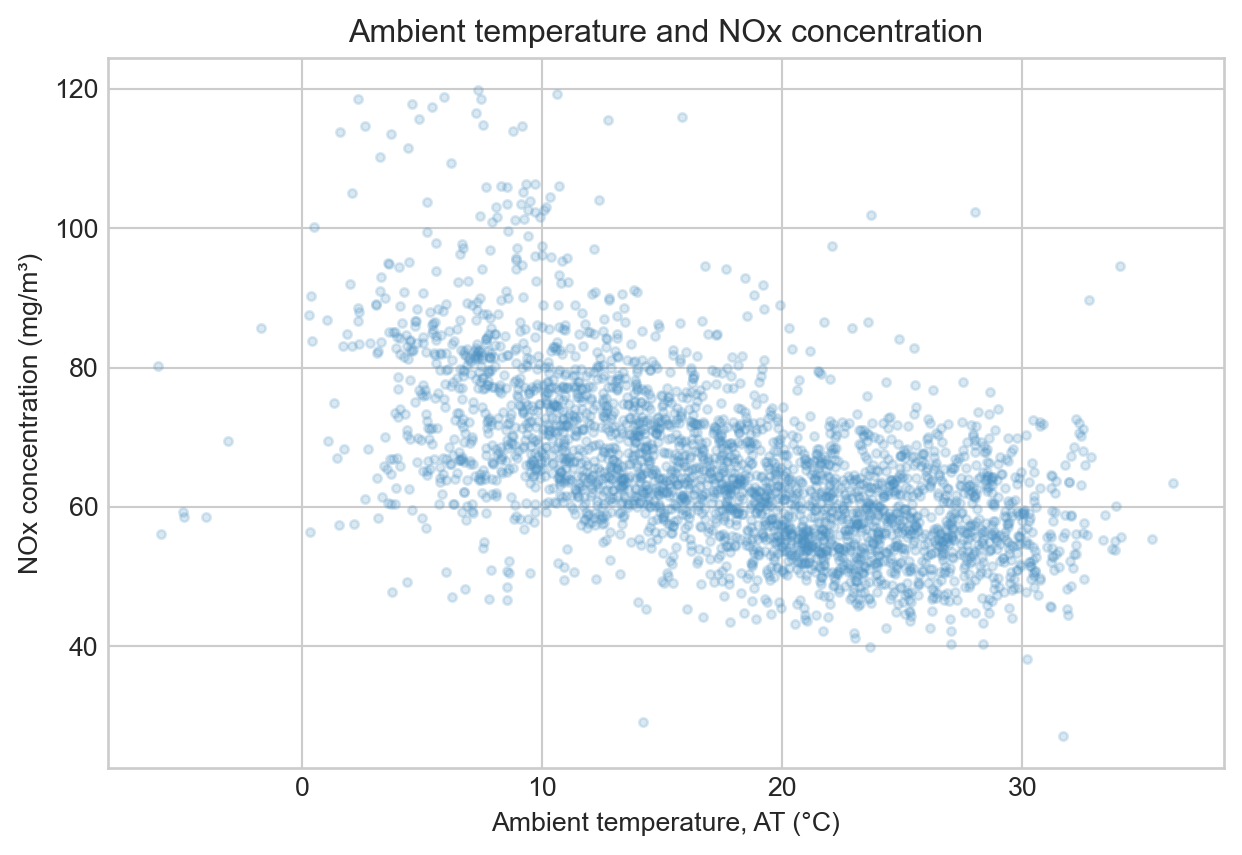

In [3]:
plot_data = regression_data.sample(n=3_000, random_state=4520)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(plot_data["AT"], plot_data["NOX"], alpha=0.2, s=10, color="#4a90c2")
ax.set(xlabel="Ambient temperature, AT (°C)", ylabel="NOx concentration (mg/m³)", title="Ambient temperature and NOx concentration")
plt.show()

The cloud slopes downward, but it is far from a perfect line.

## 5. State the model

Treat NOx concentration as the response, $Y$, and ambient temperature as the predictor, $X$:

$$
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i.
$$

A hat denotes a quantity estimated from the observed data. After fitting the model, its prediction for observation $i$ is:

$$
\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i.
$$

Thus, $\hat{y}_i$ is a predicted NOx value, while $\hat{\beta}_0$ and $\hat{\beta}_1$ are the fitted intercept and slope. The unobserved $\varepsilon_i$ in the population model is an error term; the **residual** is the observed vertical difference $e_i = y_i - \hat{y}_i$.

## 6. Choose a loss function

A raw mean residual can cancel positive and negative errors. Mean absolute error (MAE) avoids cancellation, but its absolute-value kink makes optimization less convenient. Ordinary least squares uses mean squared error (MSE):

$$
\mathcal{L}_{\mathrm{MSE}}(\beta_0, \beta_1) = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \beta_0 - \beta_1x_i\right)^2.
$$

Squaring prevents cancellation and gives larger errors more weight.

In [4]:
x = regression_data["AT"]
y = regression_data["NOX"]
candidate_lines = pd.DataFrame({"intercept": [70.0, 80.8, 90.0], "slope": [-0.50, -0.88, -1.20]}, index=["A", "B", "C"])

def residual_summaries(intercept, slope):
    residual = y - (intercept + slope * x)
    return pd.Series({"mean residual": residual.mean(), "MAE": residual.abs().mean(), "MSE": (residual**2).mean()})

loss_table = candidate_lines.apply(lambda line: residual_summaries(line["intercept"], line["slope"]), axis=1)
candidate_lines.join(loss_table)

,intercept,slope,mean residual,MAE,MSE
A,70.0,-0.50,4.149430,7.926254,118.918579
B,80.8,-0.88,0.080266,7.369149,93.897656
C,90.0,-1.20,-3.451661,8.248357,111.652396


## 7. Fit the least-squares line

Simple linear regression has a closed-form MSE minimizer. statsmodels performs that optimization after we add a constant column for the intercept.

In [5]:
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
intercept = model.params["const"]
slope = model.params["AT"]
pd.Series({"intercept (mg/m³)": intercept, "slope (mg/m³ per °C)": slope})

intercept (mg/m³)       80.796532
slope (mg/m³ per °C)    -0.875273
dtype: float64

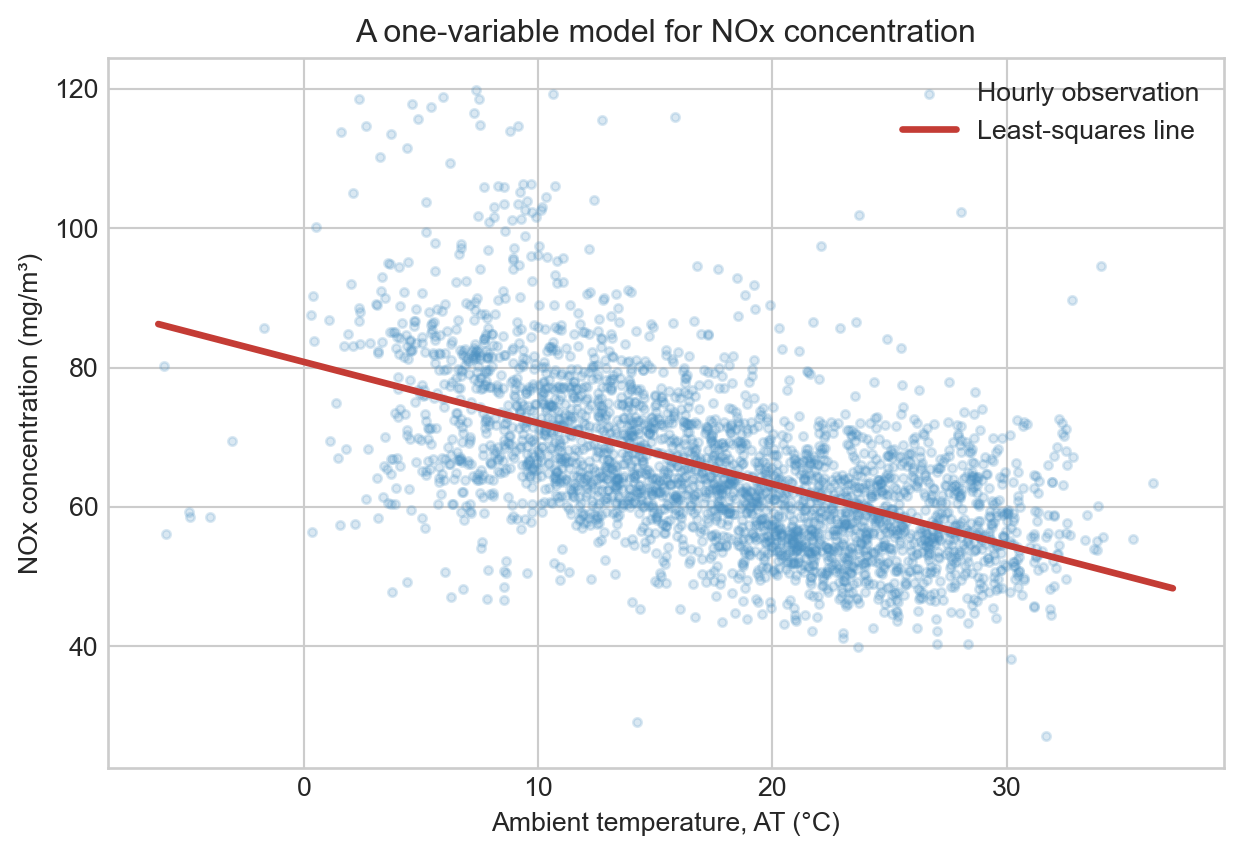

Fitted line: NOx = 80.80 -0.875 × AT


In [6]:
temperature_grid = np.linspace(x.min(), x.max(), 200)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(plot_data["AT"], plot_data["NOX"], alpha=0.2, s=10, color="#4a90c2", label="Hourly observation")
ax.plot(temperature_grid, intercept + slope * temperature_grid, color="#c43c35", linewidth=2.5, label="Least-squares line")
ax.set(xlabel="Ambient temperature, AT (°C)", ylabel="NOx concentration (mg/m³)", title="A one-variable model for NOx concentration")
ax.legend()
plt.show()
print(f"Fitted line: NOx = {intercept:.2f} {slope:+.3f} × AT")

### Interpret the slope

The fitted slope is the predicted difference in NOx concentration associated with a one-degree-Celsius difference in ambient temperature. This is an **association**, not an intervention claim.

## 8. Inspect the residuals

Residuals reveal the variation that the line leaves unexplained. Start with their distribution: what size error is typical, and are there unusually large errors? A residual histogram can assess whether a Normal approximation is plausible, but it cannot prove a Normal-error assumption.

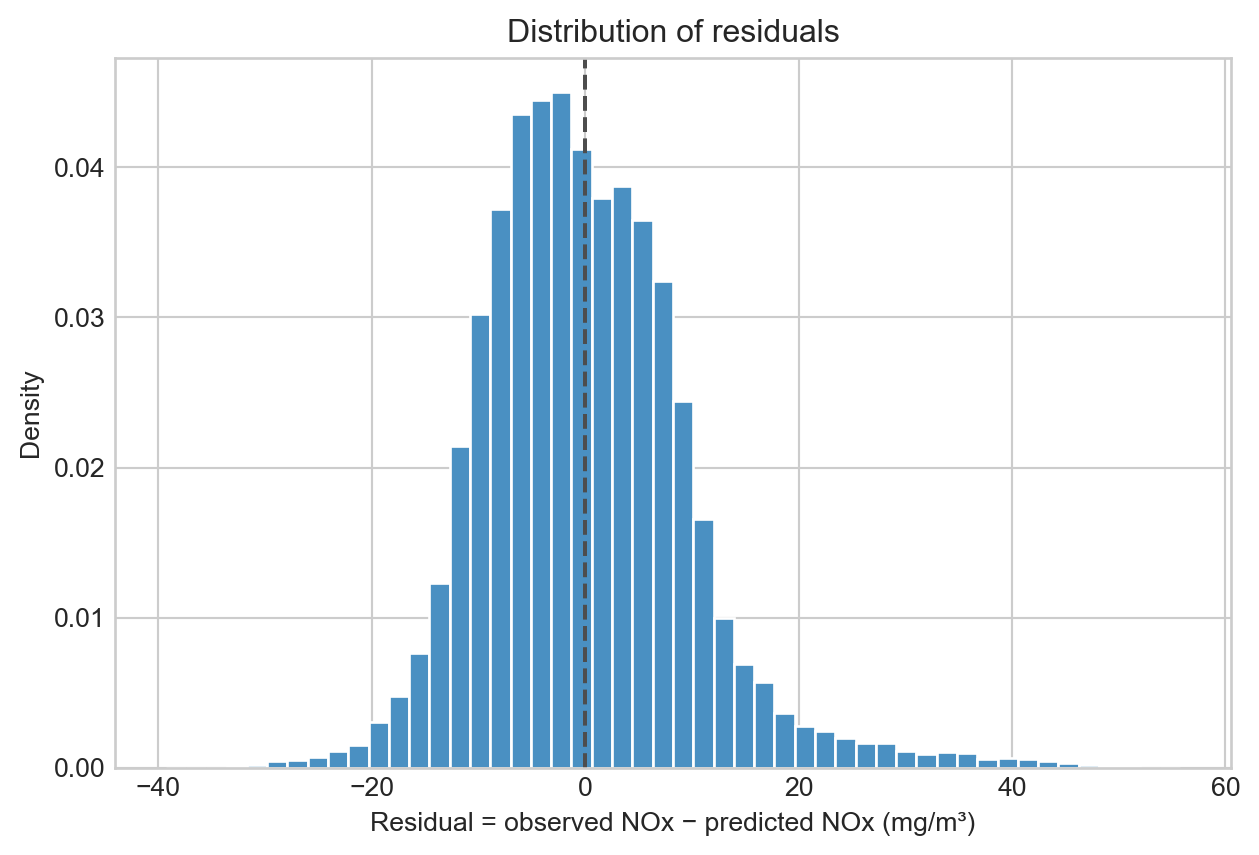

Residual mean: -9.508e-15 mg/m³
Residual SD: 9.69 mg/m³


In [7]:
residual = model.resid
residual_sd = residual.std(ddof=2)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.hist(residual, bins=50, density=True, color="#4a90c2", edgecolor="white")
ax.axvline(0, color="#4d4d4d", linestyle="--", linewidth=1.5)
ax.set(xlabel="Residual = observed NOx − predicted NOx (mg/m³)", ylabel="Density", title="Distribution of residuals")
plt.show()
print(f"Residual mean: {residual.mean():.3e} mg/m³")
print(f"Residual SD: {residual_sd:.2f} mg/m³")

A residual mean near zero is guaranteed by OLS when the model includes an intercept. More revealing questions are whether the **center** stays near zero and whether the **spread** stays about the same width across the range of AT values.

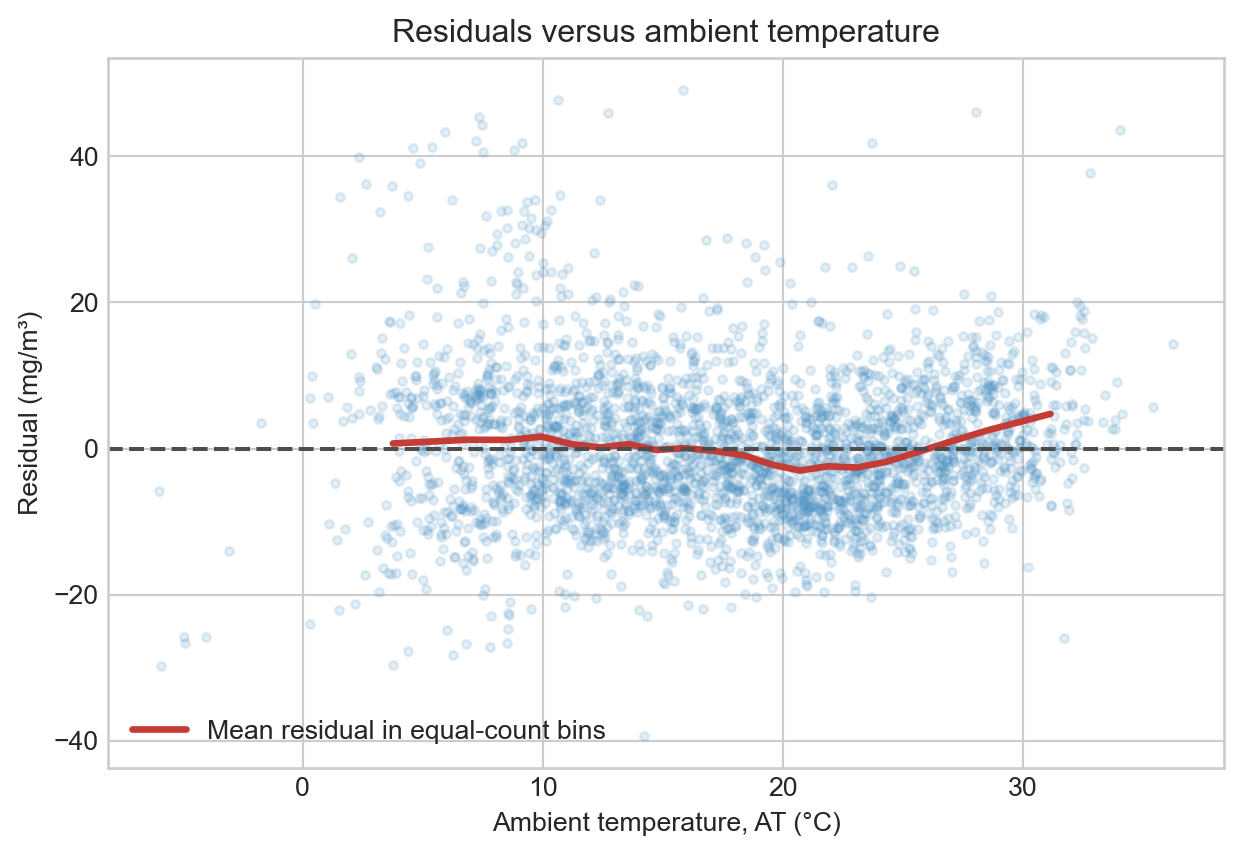

In [8]:
diagnostic_data = regression_data.assign(residual=residual)
diagnostic_sample = diagnostic_data.sample(n=3_000, random_state=4520)
binned_residuals = diagnostic_data.assign(AT_bin=lambda frame: pd.qcut(frame["AT"], 20)).groupby("AT_bin", observed=True)[["AT", "residual"]].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(diagnostic_sample["AT"], diagnostic_sample["residual"], alpha=0.15, s=10, color="#4a90c2")
ax.plot(binned_residuals["AT"], binned_residuals["residual"], color="#c43c35", linewidth=2.5, label="Mean residual in equal-count bins")
ax.axhline(0, color="#4d4d4d", linestyle="--", linewidth=1.5)
ax.set(xlabel="Ambient temperature, AT (°C)", ylabel="Residual (mg/m³)", title="Residuals versus ambient temperature")
ax.legend()
plt.show()

The red line summarizes the average residual at nearby temperature values. A pattern above and below zero suggests that a straight line misses systematic structure. A changing vertical spread suggests heteroscedasticity. These diagnostics identify useful next modeling steps, such as nonlinear features, additional predictors, or time-aware validation.

## 9. Summarize fit with $R^2$

A mean-only baseline predicts every observation with $\bar{y}$. Its total squared error is the total sum of squares (TSS). The regression's squared error is the residual sum of squares (RSS):

$$
R^2 = 1 - \frac{\mathrm{RSS}}{\mathrm{TSS}}.
$$

Thus, $R^2$ is the fraction of baseline squared error that the fitted line removes. It describes in-sample fit, not causality or future predictive accuracy.

In [9]:
mean_only_prediction = y.mean()
tss = ((y - mean_only_prediction) ** 2).sum()
rss = (residual**2).sum()
r_squared = 1 - rss / tss
pd.Series({"TSS (mean-only baseline)": tss, "RSS (regression line)": rss, "R²": r_squared})

TSS (mean-only baseline)    5.009658e+06
RSS (regression line)       3.448860e+06
R²                          3.115577e-01
dtype: float64

## Check-in

1. Why can the raw mean residual be misleading as a loss function?
2. What would a residual-versus-AT plot look like if a straight-line conditional mean were adequate?
3. If $R^2 \approx 0.31$, what does that say about the regression line relative to the mean-only baseline?

Keep your answers in your own notes. Later regression materials will introduce confidence intervals, hypothesis tests, additional predictors, and out-of-sample validation.

[Return to the Regression page](index.qmd)